# Choosing the shape parameter

The shape parameter $\epsilon$ controls how wide the basis functions are, and it is the one hyperparameter that matters. Too wide and the kernel matrix becomes so ill-conditioned that the weights are numerical noise; too narrow and the surrogate collapses into spikes around the samples.

Three searches are provided. They all sweep a range of candidates and return a `SearchResult`, and they differ only in where the error signal comes from:

- `kfold_search` — holds out folds of the sampled data
- `validation_search` — uses a separate validation set
- `gradient_search` — scores against the sampled gradients, holding nothing out

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

from ge_rbf import RBFRegressor, gradient_search, kfold_search, plot_search, validation_search


def underlying(x):
    return np.sin(3 * np.pi * x), 3 * np.pi * np.cos(3 * np.pi * x)


X = qmc.LatinHypercube(d=1, seed=3).random(9)
y, dy = underlying(X)
y = y.ravel()

x_dense = np.linspace(0, 1, 300).reshape(-1, 1)
y_dense, _ = underlying(x_dense)

## k-fold cross-validation

Pass a *template* estimator. It is cloned for every candidate and never modified, so the object you hand in comes back unfitted. The fitted winner is returned as `result.best_estimator`.

`random_state` seeds the fold shuffle, which makes the search reproducible.

In [2]:
result = kfold_search(RBFRegressor(), X, y, dy=dy, k=3, random_state=0)

print(result)
print(
    f"rejected for poor conditioning: {result.rejected} of {result.rejected + result.epsilons.size}"
)

model = result.best_estimator
print(f"returned model is fitted at epsilon = {model.epsilon:.4f}")

SearchResult(best_epsilon=5.69, best_score=0.2832, n_candidates=18, rejected=32)
rejected for poor conditioning: 32 of 50
returned model is fitted at epsilon = 5.6899


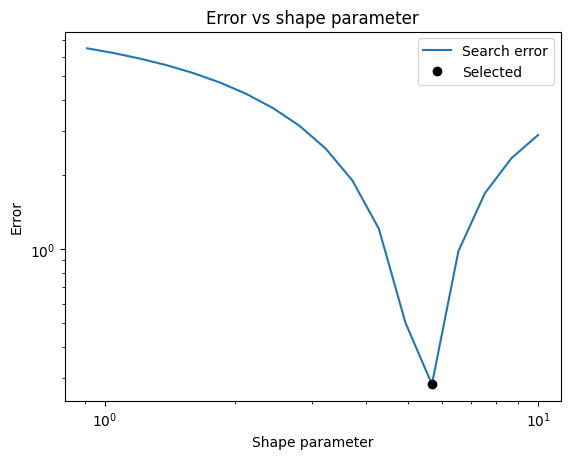

In [3]:
plot_search(result)
plt.show()

## Validation set

When extra function evaluations are cheap, scoring against a held-out set is the most direct measure of what you actually care about.

In [4]:
X_valid = qmc.LatinHypercube(d=1, seed=11).random(20)
y_valid, _ = underlying(X_valid)
y_valid = y_valid.ravel()

result_valid = validation_search(RBFRegressor(), X, y, X_valid, y_valid, dy=dy)
print(result_valid)

SearchResult(best_epsilon=2.121, best_score=0.0003465, n_candidates=16, rejected=34)


## Gradient validation

This one is the reason gradients are worth sampling even when you do not use them in the fit. Setting `use_gradients_in_fit=False` fits function-value models and scores them against the sampled gradients, which are then a genuinely independent signal — no data is held out, and no extra evaluations are needed.

In [5]:
enhanced = gradient_search(RBFRegressor(), X, y, dy)
held_out = gradient_search(RBFRegressor(), X, y, dy, use_gradients_in_fit=False)

print(
    f"gradients used in the fit:     {enhanced.best_epsilon:.4f}  (model type {enhanced.best_estimator.mode_})"
)
print(
    f"gradients held out of the fit: {held_out.best_epsilon:.4f}  (model type {held_out.best_estimator.mode_})"
)

gradients used in the fit:     2.4421  (model type ge)
gradients held out of the fit: 3.7276  (model type fv)


## Comparing the three

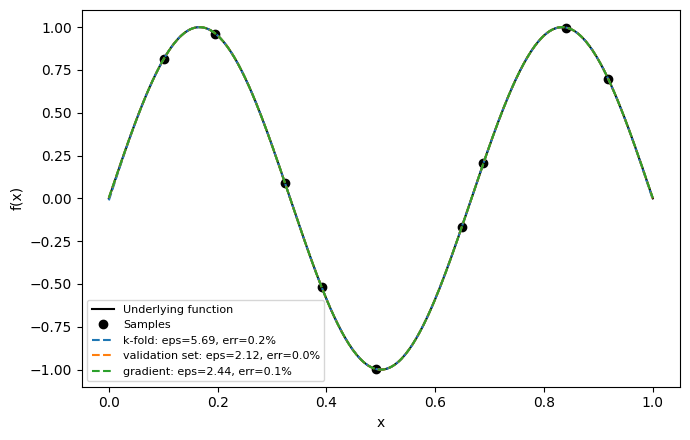

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_dense, y_dense, "k", label="Underlying function")
ax.plot(X, y, "ko", label="Samples")

for search, label in [
    (result, "k-fold"),
    (result_valid, "validation set"),
    (enhanced, "gradient"),
]:
    prediction = search.best_estimator.predict(x_dense)
    error = np.linalg.norm(prediction - y_dense.ravel()) / np.linalg.norm(y_dense)
    ax.plot(
        x_dense, prediction, "--", label=f"{label}: eps={search.best_epsilon:.2f}, err={error:.1%}"
    )

ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.legend(fontsize=8)
fig.tight_layout()

## Conditioning

`max_condition` rejects candidates whose system is too ill-conditioned to trust, *before* the winner is chosen. Tightening it changes which shape parameter is selected.

In [7]:
for ceiling in (np.inf, 1e10, 1e6):
    found = gradient_search(RBFRegressor(), X, y, dy, max_condition=ceiling)
    print(
        f"max_condition={ceiling:>8.0e}: eps={found.best_epsilon:.4f}, {found.rejected:2d} candidates rejected, worst kept condition {found.conditions.max():.2e}"
    )

max_condition=     inf: eps=2.4421,  0 candidates rejected, worst kept condition 1.70e+17
max_condition=   1e+10: eps=2.4421, 38 candidates rejected, worst kept condition 4.77e+09
max_condition=   1e+06: eps=6.5513, 46 candidates rejected, worst kept condition 8.45e+05
